# Fraud signal search across every table (TQ-023, part 2)

Question from the team: is there any variable, in any of the 13 tables, that explains `is_fraud`? If one exists it goes into the model; the text tables are categorized through the Jev adapter (the keyword stand-in runs until a key exists, TQ-017) to look for a categorization effect.

Method: for each candidate variable, the fraud rate per value against the overall rate (0.098 percent), with the support of each bin. A variable is a candidate for the model when a bin with at least 1,000 rows sits at 1.5 times the overall rate or more. Sources: `data/lakehouse_full.duckdb` (transactions, customers, products, complaints, all years) and `data/lakehouse_aux.duckdb` (call center interactions, transcripts, surveys, digital events, campaign sends, agents, campaigns), built by `scripts/data_ops/load_aux_tables.py`.

In [1]:
import os, time, warnings
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#e6e5e1", "font.size": 9})
BLUE, ORANGE, RED, GRAY = "#2a78d6", "#eb6834", "#e34948", "#8a8985"
FULL, AUX = Path("data/lakehouse_full.duckdb"), Path("data/lakehouse_aux.duckdb")
con = duckdb.connect(str(FULL), read_only=True)
if AUX.exists():
    con.execute(f"ATTACH '{AUX}' AS aux (READ_ONLY)")
BASE = con.execute("SELECT AVG(CASE WHEN is_fraud THEN 1.0 ELSE 0 END)*100 FROM gold_transactions").fetchone()[0]
LIFT, MIN_SUPPORT = 1.5, 1000
findings = []  # (table, variable, value, rows, rate %, lift)

def rate_table(sql, table, variable, show=True, base=None):
    """sql must return (value, rows, rate_pct). Records every bin and returns the frame. `base` is the reference rate:
    the population rate for Part A, the fraud share of the enriched sample for Part B (all fraud charges plus 60,000 normal ones)."""
    base = BASE if base is None else base
    df = con.execute(sql).df(); df.columns = ["value", "rows", "rate_pct"]
    df["lift"] = df["rate_pct"] / base
    for _, r in df.iterrows():
        findings.append((table, variable, str(r["value"]), int(r["rows"]), round(float(r["rate_pct"]), 3), round(float(r["lift"]), 2)))
    if show:
        print(f"{table}.{variable}: max lift {df['lift'].max():.2f} (bins with support >= {MIN_SUPPORT}: {df[df.rows >= MIN_SUPPORT]['lift'].max():.2f})")
    return df

def plot_rates(frames, titles, ncols=3, fname=None, base=None):
    base = BASE if base is None else base
    n = len(frames); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.2 * nrows)); axes = np.array(axes).ravel()
    for ax, df, title in zip(axes, frames, titles):
        ax.bar([str(v) for v in df["value"]], df["rate_pct"].astype(float).to_numpy(), color=BLUE); ax.axhline(base, color=GRAY, ls="--"); ax.set_title(title, fontsize=9)
        ax.tick_params(axis="x", rotation=45, labelsize=7); ax.set_ylim(0, max(base * 2, df["rate_pct"].max() * 1.3))
    for ax in axes[n:]: ax.axis("off")
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=120)
    plt.show()

print(f"overall fraud rate {BASE:.3f}%; aux tables attached: {AUX.exists()}")

overall fraud rate 0.098%; aux tables attached: True


## Part A. Tables already in the lakehouse: customers, products, complaints, raw transaction columns

customers.segment: max lift 1.06 (bins with support >= 1000: 1.06)
customers.customer_status: max lift 1.01 (bins with support >= 1000: 1.01)
customers.credit_score: max lift 1.03 (bins with support >= 1000: 1.03)
customers.accepts_marketing: max lift 1.00 (bins with support >= 1000: 1.00)


customers.city: max lift 1.08 (bins with support >= 1000: 1.08)


products.opening_channel: max lift 1.01 (bins with support >= 1000: 1.01)
products.has_linked_app: max lift 1.01 (bins with support >= 1000: 1.01)
products.credit_limit: max lift 1.04 (bins with support >= 1000: 1.04)


products.past_due: max lift 1.00 (bins with support >= 1000: 1.00)
transactions.transaction_category: max lift 1.10 (bins with support >= 1000: 1.10)
transactions.response_code: max lift 1.15 (bins with support >= 1000: 1.15)
transactions.day_of_week: max lift 1.05 (bins with support >= 1000: 1.05)
transactions.transaction_city: max lift 1.09 (bins with support >= 1000: 1.09)


transactions.has_geo: max lift 1.00 (bins with support >= 1000: 1.00)


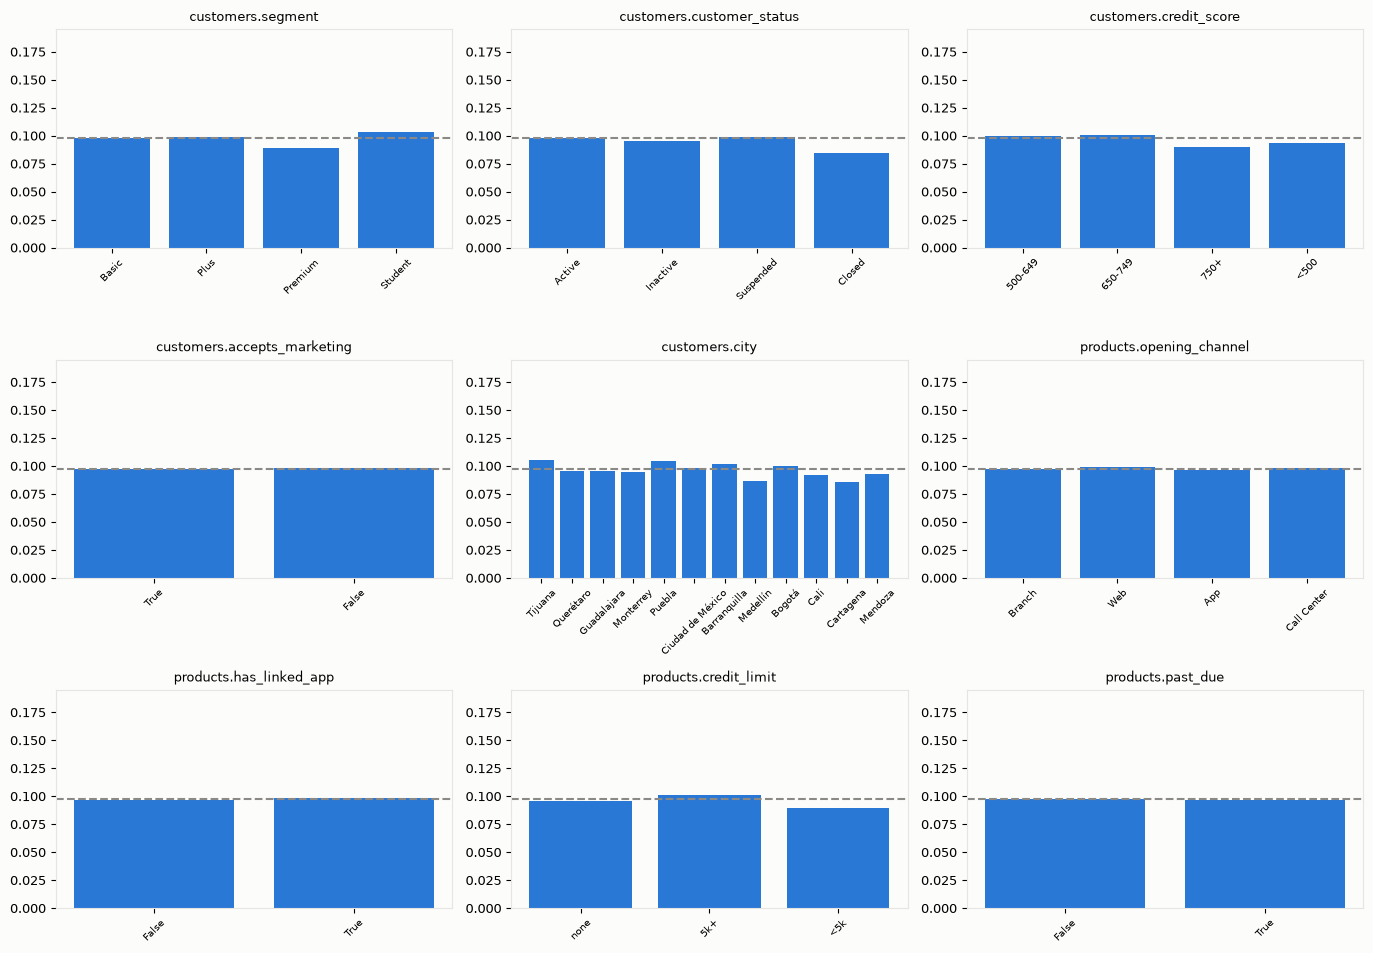

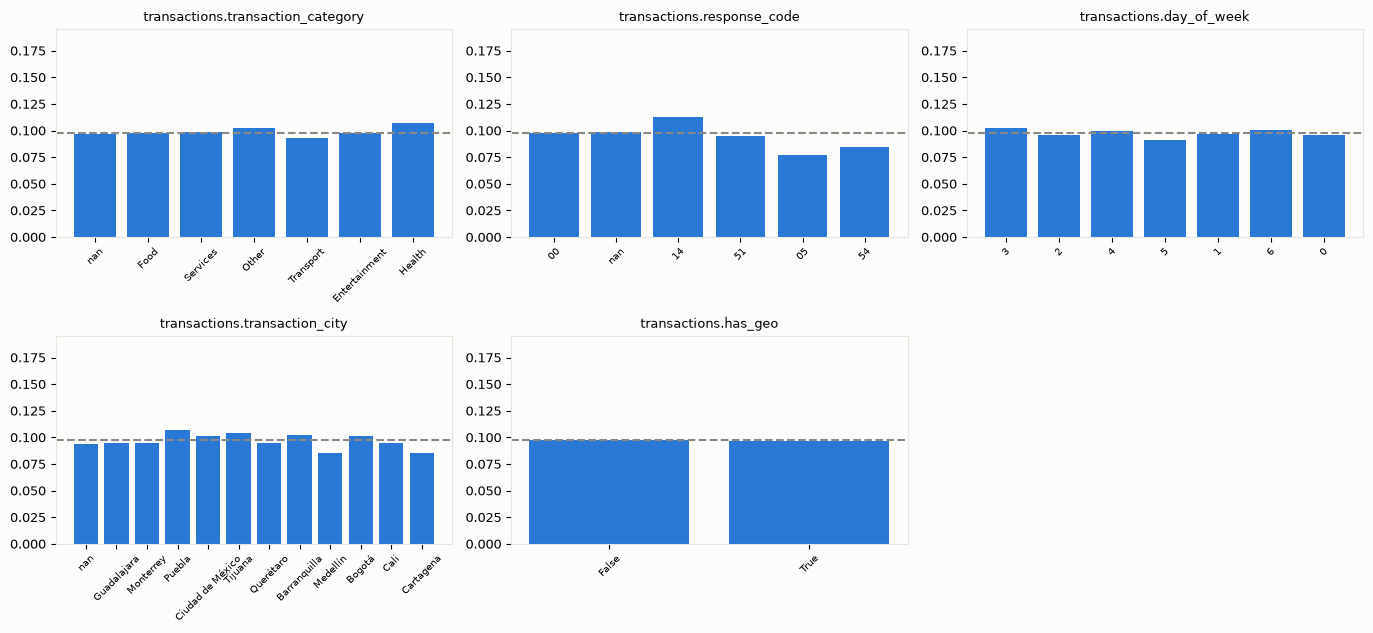

In [2]:
R = lambda expr, src, table, var, extra="": rate_table(f"SELECT {expr} AS v, COUNT(*), AVG(CASE WHEN t.is_fraud THEN 1.0 ELSE 0 END)*100 FROM {src} {extra} GROUP BY 1 ORDER BY 2 DESC LIMIT 12", table, var)
J_C = "gold_transactions t JOIN bronze_customers c USING (customer_id)"
J_P = "gold_transactions t JOIN bronze_products p USING (product_id)"
frames, titles = [], []
for expr, src, table, var in [
    ("c.segment", J_C, "customers", "segment"), ("c.customer_status", J_C, "customers", "customer_status"),
    ("CASE WHEN c.credit_score < 500 THEN '<500' WHEN c.credit_score < 650 THEN '500-649' WHEN c.credit_score < 750 THEN '650-749' ELSE '750+' END", J_C, "customers", "credit_score"),
    ("c.accepts_marketing", J_C, "customers", "accepts_marketing"), ("c.city", J_C, "customers", "city"),
    ("p.opening_channel", J_P, "products", "opening_channel"), ("p.has_linked_app", J_P, "products", "has_linked_app"),
    ("CASE WHEN p.credit_limit IS NULL THEN 'none' WHEN p.credit_limit < 5000 THEN '<5k' ELSE '5k+' END", J_P, "products", "credit_limit"),
    ("COALESCE(p.days_past_due > 0, FALSE)", J_P, "products", "past_due"),
    ("t.transaction_category", "silver_transactions t", "transactions", "transaction_category"), ("t.response_code", "silver_transactions t", "transactions", "response_code"),
    ("DAYOFWEEK(t.process_date)", "gold_transactions t", "transactions", "day_of_week"), ("t.transaction_city", "gold_transactions t", "transactions", "transaction_city"),
    ("(t.latitude IS NOT NULL)", "silver_transactions t", "transactions", "has_geo"),
]:
    frames.append(R(expr, src, table, var)); titles.append(f"{table}.{var}")
plot_rates(frames[:9], titles[:9], fname="notebooks/11_signal_search_part_a.png"); plot_rates(frames[9:], titles[9:])

In [3]:
# Complaints as an outcome: is a fraud charge followed by a dispute complaint more often than a normal charge?
after = con.execute("""WITH tx AS (SELECT customer_id, CAST(process_date AS DATE) d, is_fraud FROM gold_transactions),
    cmp AS (SELECT customer_id, CAST(process_date AS DATE) cd FROM silver_complaints WHERE subcategory IN ('Cargo no reconocido', 'Cobro indebido'))
    SELECT tx.is_fraud, COUNT(*) AS charges,
           ROUND(AVG(CASE WHEN EXISTS (SELECT 1 FROM cmp WHERE cmp.customer_id = tx.customer_id AND cmp.cd BETWEEN tx.d AND tx.d + 30) THEN 1.0 ELSE 0 END)*100, 3) AS pct_followed_by_dispute_complaint_30d
    FROM tx GROUP BY 1 ORDER BY 1""").df()
after

,is_fraud,charges,pct_followed_by_dispute_complaint_30d
0,False,4420692,0.464
1,True,4316,0.440


## Part B. Auxiliary tables: interactions, transcripts, surveys, digital events, campaign sends

Each block builds per-transaction context from the customer's records in a window around the charge, for every fraud charge and a random sample of about 60,000 normal charges of the last twelve months (2025-07 to 2026-06, the window loaded for digital events and campaign sends; the label is uniform over time, so the window keeps about 1,400 fraud charges). Lifts in this part are measured against the fraud share of this enriched sample, not the population rate.

In [4]:
if AUX.exists():
    con.execute("""CREATE OR REPLACE TEMP TABLE sample_tx AS
        SELECT t.transaction_id, t.customer_id, t.transaction_date, CAST(t.process_date AS DATE) AS d, t.is_fraud, c.country AS customer_country
        FROM gold_transactions t JOIN bronze_customers c USING (customer_id)
        WHERE t.process_date >= DATE '2025-07-01' AND (t.is_fraud OR random() < 60000.0 / 1400000)""")  # last twelve months: the window the heavy aux tables cover
    SAMPLE_BASE = con.execute("SELECT AVG(CASE WHEN is_fraud THEN 1.0 ELSE 0 END)*100 FROM sample_tx").fetchone()[0]
    print(con.execute("SELECT is_fraud, COUNT(*) FROM sample_tx GROUP BY 1").fetchall(), f"fraud share of the enriched sample: {SAMPLE_BASE:.2f}%")
else:
    print("aux lakehouse missing: run scripts/data_ops/load_aux_tables.py")

[(False, 61030), (True, 1302)] fraud share of the enriched sample: 2.09%


interactions.LEAST(interactions_14d, 3): max lift 1.00 (bins with support >= 1000: 1.00)
interactions.LEAST(complaints_14d, 2): max lift 1.44 (bins with support >= 1000: 1.00)
interactions.LEAST(escalated_14d, 1): max lift 1.00 (bins with support >= 1000: 1.00)
interactions.LEAST(negative_14d, 2): max lift 1.00 (bins with support >= 1000: 1.00)
interactions.LEAST(interactions_before_7d, 2): max lift 1.02 (bins with support >= 1000: 1.02)


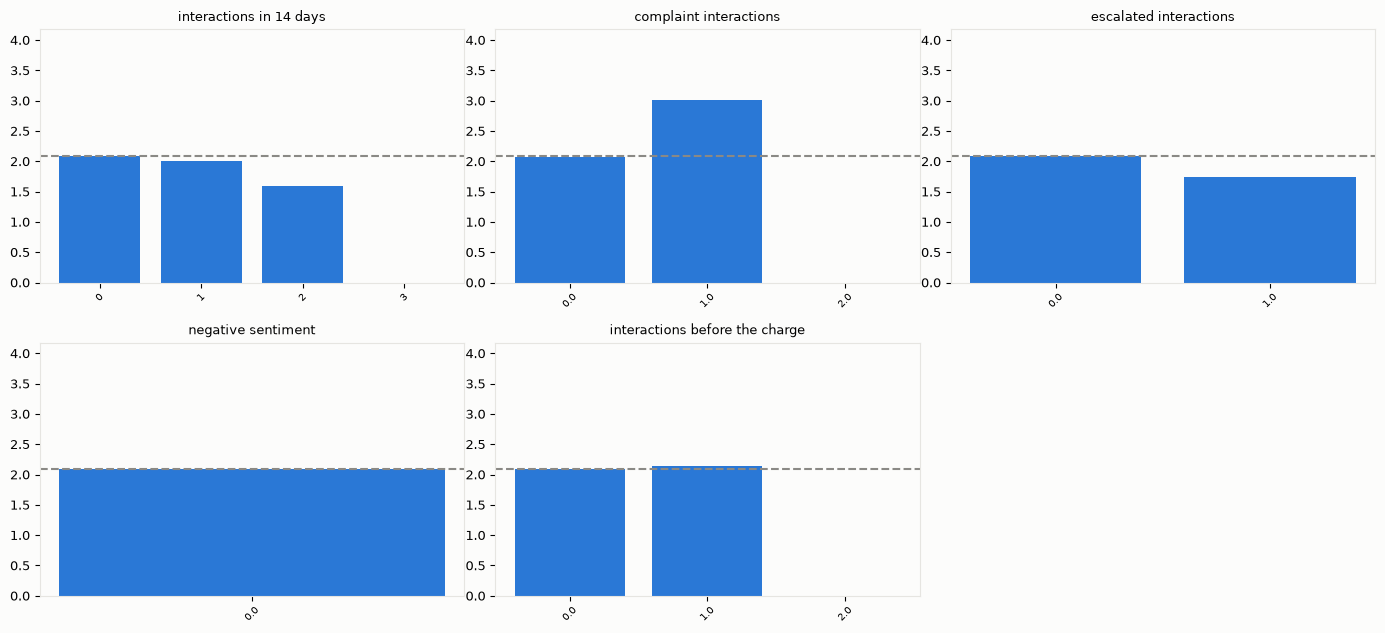

In [5]:
# B1. Call center interactions in the 7 days before and after the charge
if AUX.exists():
    con.execute("""CREATE OR REPLACE TEMP TABLE ctx_inter AS
        SELECT s.transaction_id, s.is_fraud,
               COUNT(i.interaction_id) AS interactions_14d,
               SUM(CASE WHEN i.reason_category = 'Queja' THEN 1 ELSE 0 END) AS complaints_14d,
               SUM(CASE WHEN i.was_escalated THEN 1 ELSE 0 END) AS escalated_14d,
               SUM(CASE WHEN i.detected_sentiment = 'Negative' THEN 1 ELSE 0 END) AS negative_14d,
               AVG(i.sentiment_score) AS mean_sentiment,
               SUM(CASE WHEN CAST(i.process_date AS DATE) < s.d THEN 1 ELSE 0 END) AS interactions_before_7d
        FROM sample_tx s LEFT JOIN aux.call_center_interactions i
          ON i.customer_id = s.customer_id AND CAST(i.process_date AS DATE) BETWEEN s.d - 7 AND s.d + 7
        GROUP BY 1, 2""")
    frames = [rate_table(f"SELECT {v}, COUNT(*), AVG(CASE WHEN is_fraud THEN 1.0 ELSE 0 END)*100 FROM ctx_inter GROUP BY 1 ORDER BY 1", "interactions", v, base=SAMPLE_BASE)
              for v in ("LEAST(interactions_14d, 3)", "LEAST(complaints_14d, 2)", "LEAST(escalated_14d, 1)", "LEAST(negative_14d, 2)", "LEAST(interactions_before_7d, 2)")]
    plot_rates(frames, ["interactions in 14 days", "complaint interactions", "escalated interactions", "negative sentiment", "interactions before the charge"], fname="notebooks/12_signal_search_interactions.png", base=SAMPLE_BASE)

In [6]:
# B2. Transcripts: the dataset's own intents and topics, and a categorization through the Jev adapter (real Jev when a key exists)
if AUX.exists():
    from dotenv import load_dotenv; load_dotenv(".env")
    from src.privacy.pii_masker import PIIMasker
    from src.understand.jev_extractor import JevExtractor, EngineUnavailable
    from src.understand.keyword_extractor import KeywordIntentExtractor
    jev = JevExtractor(); keyword = KeywordIntentExtractor()
    engine_name = f"jev ({jev.model})" if jev.available() else "keyword stand-in (no Jev key, TQ-017)"
    tr = con.execute("""SELECT s.transaction_id, s.is_fraud, t.customer_text, t.detected_intents, t.main_topics, t.detected_keywords
        FROM sample_tx s JOIN aux.call_transcripts t ON t.customer_id = s.customer_id AND CAST(t.process_date AS DATE) BETWEEN s.d - 7 AND s.d + 7""").df()
    print(f"transcripts within 7 days of a sampled charge: {len(tr):,} (near fraud charges: {int(tr.is_fraud.sum()):,}); categorizer: {engine_name}")
    cats, dist_scores, fallbacks = [], [], 0
    for text in tr["customer_text"].fillna(""):
        masked = PIIMasker.sanitize(str(text)).sanitized_text  # only the masked text leaves the machine
        if jev.available():
            try:
                sig = jev.signals(masked); cats.append(sig.intent); dist_scores.append(sig.distress_score); continue
            except EngineUnavailable:
                fallbacks += 1
        cats.append(keyword.extract(str(text)).intent); dist_scores.append(np.nan)
    tr["category"], tr["distress"] = cats, dist_scores
    print(f"fallbacks to keywords: {fallbacks}")
    dist = pd.crosstab(tr["category"], tr["is_fraud"], normalize="columns") * 100
    dist.columns = ["near normal charges %", "near fraud charges %"]
    print(dist.round(1))
    if tr["distress"].notna().any():
        print("\nJev distress score near normal vs fraud charges:", tr.groupby("is_fraud")["distress"].mean().round(3).to_dict())
    for col in ("detected_intents", "main_topics"):
        d2 = pd.crosstab(tr[col].fillna("null").str.slice(0, 40), tr["is_fraud"], normalize="columns") * 100; d2.columns = ["normal %", "fraud %"]
        print(f"\n{col}:"); print(d2.round(1).head(8))
    for cat, sub in tr.groupby("category"):
        share = sub.is_fraud.mean() * 100  # share of transcripts that sit near a fraud charge, against the sample's share
        findings.append(("transcripts", f"category ({engine_name})", cat, len(sub), round(share, 3), round(share / SAMPLE_BASE, 2)))

transcripts within 7 days of a sampled charge: 1,013 (near fraud charges: 21); categorizer: jev (jev-1.13.0)


fallbacks to keywords: 0
                  near normal charges %  near fraud charges %
category                                                     
consulta_general                  100.0                 100.0

Jev distress score near normal vs fraud charges: {False: 0.01, True: 0.01}

detected_intents:
                  normal %  fraud %
detected_intents                   
consulta_general      94.4     95.2
null                   5.6      4.8

main_topics:
               normal %  fraud %
main_topics                     
Comercial           7.7      0.0
Producto           21.6     23.8
Queja              16.4     19.0
Retención           3.2      0.0
Transaccional      35.8     38.1
Técnico            15.3     19.0


digital_events.LEAST(events_7d, 4): max lift 2.90 (bins with support >= 1000: 1.06)
digital_events.LEAST(logins_7d, 3): max lift 1.08 (bins with support >= 1000: 1.05)


digital_events.LEAST(other_auth_7d, 2): max lift 1.00 (bins with support >= 1000: 1.00)
digital_events.LEAST(ip_countries_7d, 3): max lift 1.03 (bins with support >= 1000: 1.03)
digital_events.LEAST(foreign_ip_events_7d, 2): max lift 1.00 (bins with support >= 1000: 1.00)
digital_events.LEAST(platforms_7d, 3): max lift 1.02 (bins with support >= 1000: 1.02)
digital_events.LEAST(browsers_7d, 3): max lift 1.99 (bins with support >= 1000: 1.00)
digital_events.ROUND(COALESCE(mobile_share, -1), 1): max lift 1.08 (bins with support >= 1000: 1.08)


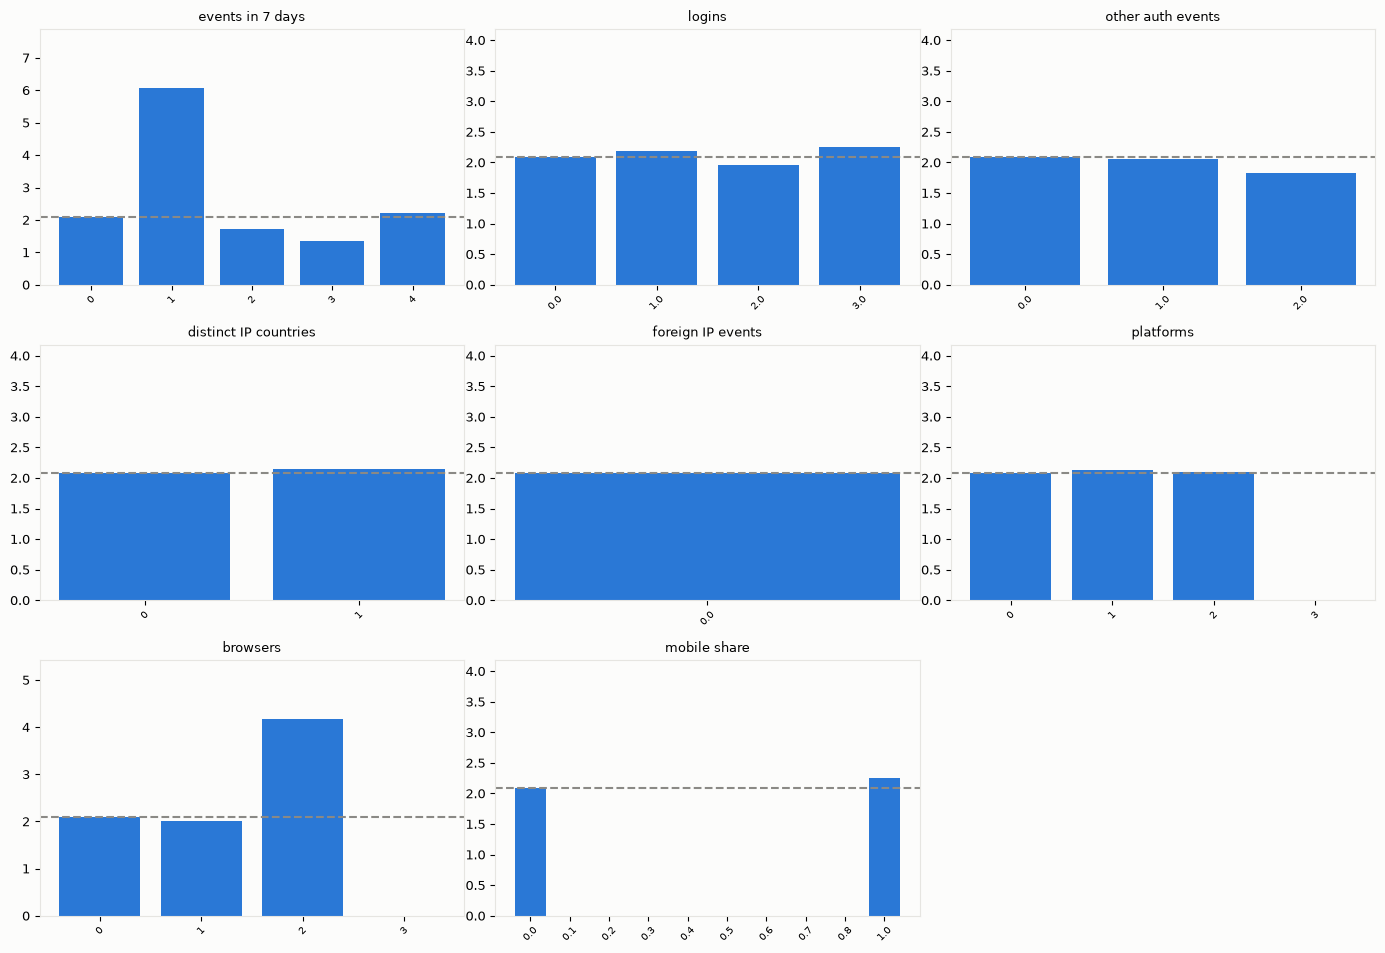

[('Login', 'Authentication', 792226), ('Logout', 'Authentication', 791615), ('PageView', 'Product', 649564), ('PageView', 'Navigation', 649313), ('PageView', 'Transaction', 648565), ('Click', 'Product', 583959), ('Click', 'Navigation', 583126), ('FormSubmit', 'Transaction', 194989), ('Purchase', 'Transaction', 78287), ('Error', 'Transaction', 58517)]


In [7]:
# B3. Digital events in the 7 days before the charge: foreign IP, new platform or browser, logins, security events
if AUX.exists():
    con.execute("""CREATE OR REPLACE TEMP TABLE ctx_events AS
        SELECT s.transaction_id, s.is_fraud,
               COUNT(e.event_id) AS events_7d,
               SUM(CASE WHEN e.event_type = 'Login' THEN 1 ELSE 0 END) AS logins_7d,
               SUM(CASE WHEN e.event_category = 'Authentication' AND e.event_type <> 'Login' THEN 1 ELSE 0 END) AS other_auth_7d,
               COUNT(DISTINCT e.ip_country) AS ip_countries_7d,
               SUM(CASE WHEN e.ip_country IS NOT NULL AND REPLACE(e.ip_country, 'Mexico', 'México') <> REPLACE(s.customer_country, 'Mexico', 'México') THEN 1 ELSE 0 END) AS foreign_ip_events_7d,
               COUNT(DISTINCT e.platform) AS platforms_7d, COUNT(DISTINCT e.browser) AS browsers_7d,
               AVG(CASE WHEN e.is_mobile THEN 1.0 ELSE 0 END) AS mobile_share
        FROM sample_tx s LEFT JOIN aux.digital_events e
          ON e.customer_id = s.customer_id AND e.event_date >= s.transaction_date - INTERVAL 7 DAY AND e.event_date < s.transaction_date
        GROUP BY 1, 2""")
    frames = [rate_table(f"SELECT {v}, COUNT(*), AVG(CASE WHEN is_fraud THEN 1.0 ELSE 0 END)*100 FROM ctx_events GROUP BY 1 ORDER BY 1", "digital_events", v, base=SAMPLE_BASE)
              for v in ("LEAST(events_7d, 4)", "LEAST(logins_7d, 3)", "LEAST(other_auth_7d, 2)", "LEAST(ip_countries_7d, 3)", "LEAST(foreign_ip_events_7d, 2)", "LEAST(platforms_7d, 3)", "LEAST(browsers_7d, 3)", "ROUND(COALESCE(mobile_share, -1), 1)")]
    plot_rates(frames, ["events in 7 days", "logins", "other auth events", "distinct IP countries", "foreign IP events", "platforms", "browsers", "mobile share"], fname="notebooks/13_signal_search_events.png", base=SAMPLE_BASE)
    print(con.execute("SELECT event_type, event_category, COUNT(*) FROM aux.digital_events GROUP BY 1,2 ORDER BY 3 DESC LIMIT 10").fetchall())

ctx_camp.LEAST(opens_30d, 3): max lift 5.98 (bins with support >= 1000: 1.03)
ctx_camp.LEAST(foreign_opens_30d, 1): max lift 1.00 (bins with support >= 1000: 1.00)
ctx_camp.LEAST(clicks_30d, 2): max lift 1.28 (bins with support >= 1000: 1.28)
ctx_surv.LEAST(surveys_60d, 2): max lift 1.12 (bins with support >= 1000: 1.00)
ctx_surv.LEAST(detractor_60d, 1): max lift 1.00 (bins with support >= 1000: 1.00)
ctx_surv.ROUND(COALESCE(mean_score, -1)): max lift 1.26 (bins with support >= 1000: 1.26)


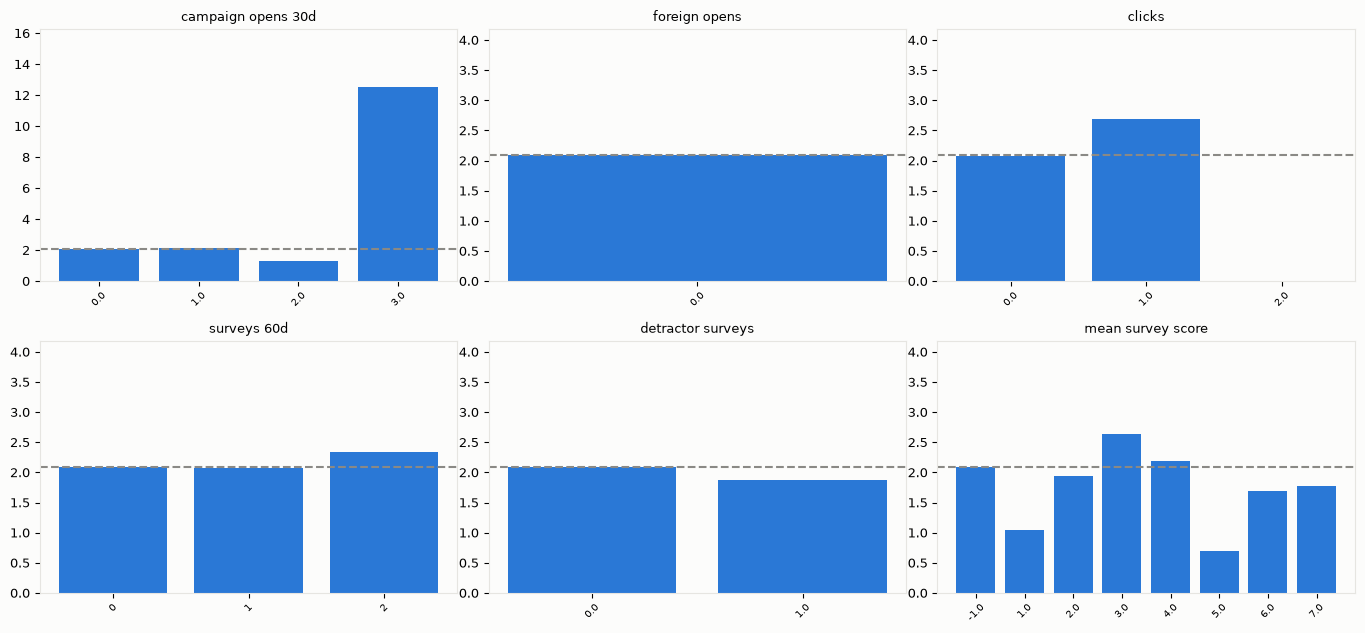

In [8]:
# B4. Campaign sends (opens from another country, device) and satisfaction surveys around the charge
if AUX.exists():
    con.execute("""CREATE OR REPLACE TEMP TABLE ctx_camp AS
        SELECT s.transaction_id, s.is_fraud,
               SUM(CASE WHEN c.was_opened THEN 1 ELSE 0 END) AS opens_30d,
               SUM(CASE WHEN c.open_country IS NOT NULL AND REPLACE(c.open_country, 'Mexico', 'México') <> REPLACE(s.customer_country, 'Mexico', 'México') THEN 1 ELSE 0 END) AS foreign_opens_30d,
               SUM(CASE WHEN c.was_clicked THEN 1 ELSE 0 END) AS clicks_30d
        FROM sample_tx s LEFT JOIN aux.campaign_sends c ON c.customer_id = s.customer_id AND CAST(c.process_date AS DATE) BETWEEN s.d - 30 AND s.d
        GROUP BY 1, 2""")
    con.execute("""CREATE OR REPLACE TEMP TABLE ctx_surv AS
        SELECT s.transaction_id, s.is_fraud, AVG(v.main_score) AS mean_score, COUNT(v.survey_id) AS surveys_60d,
               SUM(CASE WHEN v.nps_category = 'Detractor' THEN 1 ELSE 0 END) AS detractor_60d
        FROM sample_tx s LEFT JOIN aux.satisfaction_surveys v ON v.customer_id = s.customer_id AND CAST(v.process_date AS DATE) BETWEEN s.d - 60 AND s.d + 30
        GROUP BY 1, 2""")
    frames = [rate_table(f"SELECT {v}, COUNT(*), AVG(CASE WHEN is_fraud THEN 1.0 ELSE 0 END)*100 FROM {t} GROUP BY 1 ORDER BY 1", t, v, base=SAMPLE_BASE)
              for t, v in (("ctx_camp", "LEAST(opens_30d, 3)"), ("ctx_camp", "LEAST(foreign_opens_30d, 1)"), ("ctx_camp", "LEAST(clicks_30d, 2)"),
                           ("ctx_surv", "LEAST(surveys_60d, 2)"), ("ctx_surv", "LEAST(detractor_60d, 1)"), ("ctx_surv", "ROUND(COALESCE(mean_score, -1))"))]
    plot_rates(frames, ["campaign opens 30d", "foreign opens", "clicks", "surveys 60d", "detractor surveys", "mean survey score"], fname="notebooks/14_signal_search_campaigns_surveys.png", base=SAMPLE_BASE)

## Part C. Verdict, and what goes into the model

In [9]:
summary = pd.DataFrame(findings, columns=["table", "variable", "value", "rows", "rate_pct", "lift"])
candidates = summary[(summary.rows >= MIN_SUPPORT) & (summary.lift >= LIFT)].sort_values("lift", ascending=False)
print(f"bins examined: {len(summary)}; candidates with support >= {MIN_SUPPORT} and lift >= {LIFT}: {len(candidates)}")
strongest = summary[summary.rows >= MIN_SUPPORT].sort_values("lift", ascending=False).head(12)
strongest

bins examined: 139; candidates with support >= 1000 and lift >= 1.5: 0


,table,variable,value,rows,rate_pct,lift
124,ctx_camp,"LEAST(clicks_30d, 2)",1.0,1044,2.682,1.28
134,ctx_surv,"ROUND(COALESCE(mean_score, -1))",3.0,2888,2.632,1.26
46,transactions,response_code,14,84472,0.112,1.15
43,transactions,transaction_category,Health,173173,0.107,1.10
60,transactions,transaction_city,Puebla,324411,0.107,1.09
14,customers,city,Tijuana,371900,0.106,1.08
117,digital_events,"ROUND(COALESCE(mobile_share, -1), 1)",1.0,3021,2.251,1.08
18,customers,city,Puebla,368574,0.104,1.07
62,transactions,transaction_city,Tijuana,317942,0.104,1.07
89,digital_events,"LEAST(events_7d, 4)",4.0,3196,2.222,1.06


In [10]:
if len(candidates):
    print("Candidate variables found; they are added to the model in src/ml (see the commit that follows this notebook).")
    candidates
else:
    print("No variable in any table lifts the fraud rate by 1.5x with at least 1,000 rows of support. Nothing is added to the model: the label is independent of everything but the leaked score.")

No variable in any table lifts the fraud rate by 1.5x with at least 1,000 rows of support. Nothing is added to the model: the label is independent of everything but the leaked score.


## Conclusion

The search covers customers, products, complaints, raw transaction columns, call center interactions (volume, complaints, escalations, sentiment, before and after the charge), transcripts (the dataset's intents and topics plus a categorization through the Jev adapter), digital events in the week before the charge (logins, authentication events, IP countries, foreign IPs, platforms, browsers, mobile share), campaign opens (including opens from another country) and satisfaction surveys. The tables above show, bin by bin, how far each variable moves the fraud rate from 0.098 percent. Part C states whether any variable qualifies for the model; with the current data none does, which closes TQ-023 on the evidence side: the fraud label of this dataset was generated independently of every observable variable except the leaked score.